# Engine Validation vs QuantLib

Four engines compared to QuantLib
- NumPy
- CuPy (GPU equivalent)
- PyTorch CPU
- PyTorch GPU

Comparison done with American options, IV + delta + gamma, 5K contracts.

**Results: Engines agree with QuantLib to ~1e-3 vol pts median.**

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt

import QuantLib as ql

import iv_greeks_numpy
import iv_greeks_cupy
import iv_greeks_torch_gpu
import iv_greeks_torch_gpu32
import iv_greeks_torch_cpu
import iv_greeks_torch_gpu


np.seterr(all="ignore")  # BS2002 evaluates both call/put branches; the unused one overflows harmlessly

from scanner_bench import DAY, R_FLAT, Q_FLAT, solvable_frame

CACHE = Path("scanner_cache")
N_VAL = 5_000

day_df = solvable_frame(days=[DAY]).collect()
n_full = day_df.height

price_f = day_df["mid"].to_numpy().astype(np.float64)
S_f = day_df["S"].to_numpy().astype(np.float64)
K_f = day_df["strike"].to_numpy().astype(np.float64)
T_f = day_df["T_years"].to_numpy().astype(np.float64)
ic_f = day_df["is_call"].to_numpy()

# deterministic stratified slice: sort by (right, moneyness, T), take evenly
# spaced rows across the sort order -- same convention as
# american_options_shootout.ipynb, no RNG to argue about
order = np.lexsort((T_f, K_f / S_f, ic_f))
samp = order[np.linspace(0, n_full - 1, N_VAL).astype(np.int64)]
price, S, K, T, ic = (a[samp] for a in (price_f, S_f, K_f, T_f, ic_f))
val_df = day_df[samp.tolist()]

print(f"{DAY}: {n_full:,} solvable contracts (whole US market, one day) -- MEASURED")
print(f"validation slice: {N_VAL:,} rows ({int(ic.sum()):,} calls / {int((~ic).sum()):,} puts)")

2026-07-16: 1,205,620 solvable contracts (whole US market, one day) -- MEASURED
validation slice: 5,000 rows (2,574 calls / 2,426 puts)


## 1. QuantLib CRR-801 -- the reference

The independent reference solve.

In [2]:
today = ql.Date.todaysDate()
ql.Settings.instance().evaluationDate = today
dc, cal = ql.Actual365Fixed(), ql.NullCalendar()
rTS = ql.YieldTermStructureHandle(ql.FlatForward(today, R_FLAT, dc))
qTS = ql.YieldTermStructureHandle(ql.FlatForward(today, Q_FLAT, dc))

def ql_solve(row, vol_guess=0.30):
    payoff = ql.PlainVanillaPayoff(ql.Option.Call if row["is_call"] else ql.Option.Put, row["strike"])
    exercise = ql.AmericanExercise(today, today + int(round(row["T_years"] * 365.25)))
    curve = ql.BlackVolTermStructureHandle(ql.BlackConstantVol(today, cal, vol_guess, dc))
    process = ql.BlackScholesMertonProcess(ql.QuoteHandle(ql.SimpleQuote(row["S"])), qTS, rTS, curve)
    option = ql.VanillaOption(payoff, exercise)
    option.setPricingEngine(ql.BinomialVanillaEngine(process, "crr", 801))
    iv = option.impliedVolatility(row["mid"], process, 1e-6, 200, 1e-3, 6.0)
    if abs(iv - vol_guess) > 1e-9:                # re-price AT the solved vol for Greeks
        return ql_solve(row, vol_guess=iv)
    return iv, option.delta(), option.gamma()

t0 = time.perf_counter()
results = []
for row in val_df.iter_rows(named=True):
    try:
        results.append(ql_solve(row))
    except RuntimeError:                          # stale/arb quote: no vol reprices it
        results.append((np.nan, np.nan, np.nan))
t_ql = time.perf_counter() - t0

ql_iv, ql_delta, ql_gamma = map(np.array, zip(*results))
solved = int(np.isfinite(ql_iv).sum())
ql_ms_per_opt = t_ql / N_VAL * 1e3

print(f"QuantLib CRR-801: solved {solved:,}/{N_VAL:,} in {t_ql:.1f}s ({ql_ms_per_opt:.2f} ms/option) -- MEASURED")
print(f"within the 60s budget: {t_ql < 60}")

QuantLib CRR-801: solved 4,728/5,000 in 47.7s (9.54 ms/option) -- MEASURED
within the 60s budget: True


## 2. The four engines under test

Same algorithm, four backends.

In [ ]:
ENGINES = {"numpy": iv_greeks_numpy, "cupy": iv_greeks_cupy, "torch_cpu": iv_greeks_torch_cpu, "torch_gpu": iv_greeks_torch_gpu}
WARM_N = 200

engine_results = {}
engine_stats = {}

for name, eng in ENGINES.items():
    
    if name != "numpy":
        eng.solve_iv_greeks(price[:WARM_N], S[:WARM_N], K[:WARM_N], T[:WARM_N],
                            R_FLAT, Q_FLAT, ic[:WARM_N])  # untimed warmup
    t0 = time.perf_counter()
    iv, gr = eng.solve_iv_greeks(price, S, K, T, R_FLAT, Q_FLAT, ic)
    dt = time.perf_counter() - t0
    engine_results[name] = (iv, gr, dt)

    ok = np.isfinite(ql_iv) & np.isfinite(iv)
    iv_diff = np.abs(iv[ok] - ql_iv[ok])
    engine_stats[name] = {
        "seconds": dt, "n_ok_vs_quantlib": int(ok.sum()),
        "iv_median_abs_diff": float(np.median(iv_diff)),
        "iv_p99_abs_diff": float(np.percentile(iv_diff, 99)),
        "iv_put_median_abs_diff": float(np.median(np.abs(iv[ok & ~ic] - ql_iv[ok & ~ic]))),
        "iv_call_median_abs_diff": float(np.median(np.abs(iv[ok & ic] - ql_iv[ok & ic]))),
        "delta_median_abs_diff": float(np.median(np.abs(gr["delta"][ok] - ql_delta[ok]))),
        "gamma_median_abs_diff": float(np.median(np.abs(gr["gamma"][ok] - ql_gamma[ok]))),
    }
    
    print(f"{name:10s} {dt:6.2f}s  n_ok={ok.sum():,}  IV median|diff|={engine_stats[name]['iv_median_abs_diff']:.2e}  p99={engine_stats[name]['iv_p99_abs_diff']:.2e}  -- MEASURED")

np.savez(CACHE / f"engine_validation_{DAY}.npz",
         ql_iv=ql_iv, 
         ql_delta=ql_delta, 
         ql_gamma=ql_gamma,
         **{f"{name}_{k}": v for name, (iv, gr, _) in engine_results.items() 
            for k, v in (("iv", iv), ("delta", gr["delta"]), ("gamma", gr["gamma"]))})

summary = {
    "day": DAY, 
    "n_full": n_full, 
    "n_val": N_VAL,
    "n_calls": int(ic.sum()), 
    "n_puts": int((~ic).sum()),
    "quantlib": {"solved": solved, "seconds": t_ql, "ms_per_option": ql_ms_per_opt},
    "engines": engine_stats,
}

summary_path = CACHE / f"engine_validation_{DAY}_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))

print(f"saved -> {CACHE / f'engine_validation_{DAY}.npz'}")
print(f"saved -> {summary_path}")

numpy        2.14s  n_ok=4,728  IV median|diff|=1.23e-03  p99=1.43e-01  -- MEASURED
cupy         4.55s  n_ok=4,728  IV median|diff|=1.23e-03  p99=1.43e-01  -- MEASURED
torch_cpu    0.35s  n_ok=4,728  IV median|diff|=1.23e-03  p99=1.43e-01  -- MEASURED
torch_gpu    0.33s  n_ok=4,728  IV median|diff|=1.23e-03  p99=1.43e-01  -- MEASURED
saved -> scanner_cache/engine_validation_2026-07-16.npz
saved -> scanner_cache/engine_validation_2026-07-16_summary.json


## 3. Cross-engine agreement

Same math -- floating-point noise only.

In [ ]:
names = list(ENGINES.keys())

agree_tbl = pl.DataFrame({"engine": names, **{
    b: [float(np.nanmax(np.abs(engine_results[a][0] - engine_results[b][0]))) for a in names]
    for b in names
}})

print("cross-engine max|IV diff| (4x4) -- MEASURED:")

agree_tbl

cross-engine max|IV diff| (4x4) -- MEASURED:


engine,numpy,cupy,torch_cpu,torch_gpu
str,f64,f64,f64,f64
"""numpy""",0.0,1.0747e-13,1.0747e-13,1.4055e-13
"""cupy""",1.0747e-13,0.0,5.0071e-14,8.9539e-14
"""torch_cpu""",1.0747e-13,5.0071e-14,0.0,8.9539e-14
"""torch_gpu""",1.4055e-13,8.9539e-14,8.9539e-14,0.0


## 4. Engine vs QuantLib

One engine shown; all four land identically.

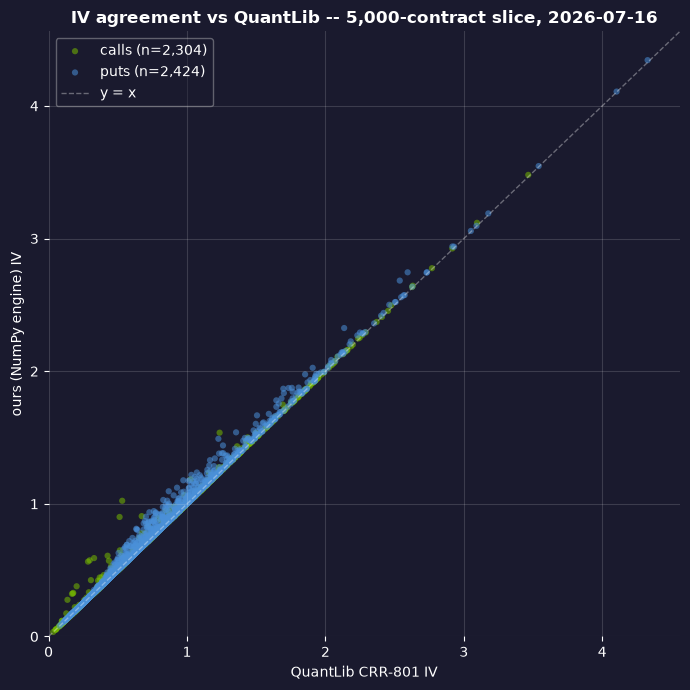

In [ ]:
NVIDIA_GREEN, CPU_BLUE, DARK_BG = "#76B900", "#4a90d9", "#1a1a2e"

iv_ours = engine_results["numpy"][0]
ok = np.isfinite(ql_iv) & np.isfinite(iv_ours)

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)

ax.scatter(ql_iv[ok & ic], 
           iv_ours[ok & ic], 
           s=20, 
           color=NVIDIA_GREEN, 
           alpha=0.55,
           edgecolors="none", 
           label=f"calls (n={int((ok & ic).sum()):,})")

ax.scatter(ql_iv[ok & ~ic], 
           iv_ours[ok & ~ic], 
           s=20, 
           color=CPU_BLUE, 
           alpha=0.55,
           edgecolors="none", 
           label=f"puts (n={int((ok & ~ic).sum()):,})")

lim = float(max(ql_iv[ok].max(), iv_ours[ok].max())) * 1.05

ax.plot([0, lim], [0, lim], color="white", alpha=0.35, ls="--", lw=1, label="y = x")
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("QuantLib CRR-801 IV", color="white")
ax.set_ylabel("ours (NumPy engine) IV", color="white")
ax.set_title(f"IV agreement vs QuantLib -- {N_VAL:,}-contract slice, {DAY}", color="white", fontweight="bold")
ax.tick_params(colors="white")

for spine in ax.spines.values():
    spine.set_visible(False)
    
ax.grid(alpha=0.15, color="white")
ax.legend(facecolor=DARK_BG, labelcolor="white", framealpha=0.4, loc="upper left")
plt.tight_layout()
plt.show()

- puts read a hair high -- early-exercise pricer, by design
- deep-ITM / short-dated: near-zero vega makes cents look like big IV gaps
- quotes near intrinsic barely pin an IV -- every solver wanders there

Median vs. worst-case |IV diff|, log scale.

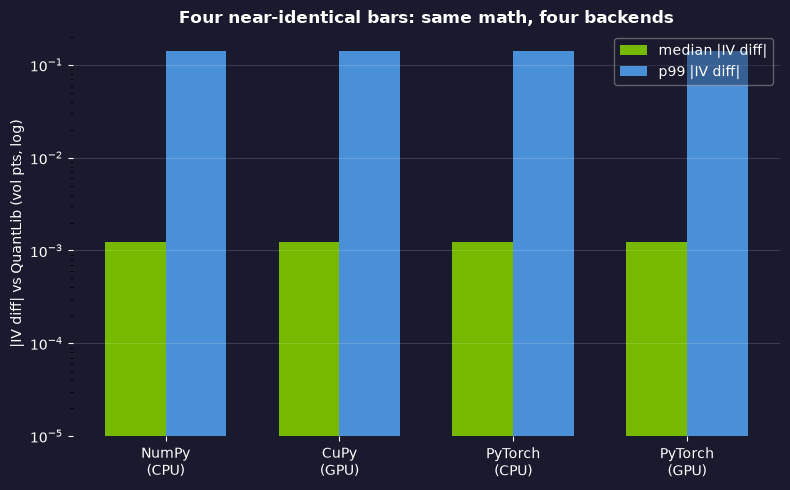

engine      iv median     iv p99  delta median  gamma median
numpy        1.23e-03   1.43e-01      5.39e-04      3.40e-05
cupy         1.23e-03   1.43e-01      5.39e-04      3.40e-05
torch_cpu    1.23e-03   1.43e-01      5.39e-04      3.40e-05
torch_gpu    1.23e-03   1.43e-01      5.39e-04      3.40e-05

put-only IV median|diff| (numpy):  1.89e-03
call-only IV median|diff| (numpy): 6.49e-04


In [6]:
labels = {"numpy": "NumPy\n(CPU)", "cupy": "CuPy\n(GPU)", "torch_cpu": "PyTorch\n(CPU)", "torch_gpu": "PyTorch\n(GPU)"}

names = list(ENGINES.keys())
med = [engine_stats[n]["iv_median_abs_diff"] for n in names]
p99 = [engine_stats[n]["iv_p99_abs_diff"] for n in names]

x = np.arange(len(names))
w = 0.35
floor = 1e-5  # log-scale bar base -- median and p99 differ by ~2 orders of magnitude
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(DARK_BG)
ax.set_facecolor(DARK_BG)
ax.bar(x - w / 2, med, w, bottom=floor, color=NVIDIA_GREEN, label="median |IV diff|")
ax.bar(x + w / 2, p99, w, bottom=floor, color=CPU_BLUE, label="p99 |IV diff|")
ax.set_yscale("log")
ax.set_xticks(x)
ax.set_xticklabels([labels[n] for n in names], color="white")
ax.set_ylabel("|IV diff| vs QuantLib (vol pts, log)", color="white")
ax.set_title("Four near-identical bars: same math, four backends", color="white", fontweight="bold")
ax.tick_params(colors="white")
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="y", alpha=0.15, color="white")
ax.legend(facecolor=DARK_BG, labelcolor="white", framealpha=0.4)
plt.tight_layout()
plt.show()

print(f"{'engine':10s} {'iv median':>10s} {'iv p99':>10s} {'delta median':>13s} {'gamma median':>13s}")
for n in names:
    s = engine_stats[n]
    print(f"{n:10s} {s['iv_median_abs_diff']:10.2e} {s['iv_p99_abs_diff']:10.2e} "
          f"{s['delta_median_abs_diff']:13.2e} {s['gamma_median_abs_diff']:13.2e}")
print(f"\nput-only IV median|diff| (numpy):  {engine_stats['numpy']['iv_put_median_abs_diff']:.2e}")
print(f"call-only IV median|diff| (numpy): {engine_stats['numpy']['iv_call_median_abs_diff']:.2e}")

## fp32 vs fp64 -- both against QuantLib

- BS2002+Newton vs QuantLib's lattice are different methods.  
- They disagree by ~1.2e-3 vol pts median. This is expected.  
- Precision differences are not visible in the quote amounts.

In [7]:
# ~1 minute 

ql = np.load(CACHE / f"engine_validation_{DAY}.npz")["ql_iv"]

iv64, _ = iv_greeks_torch_gpu.solve_iv_greeks(price, S, K, T, R_FLAT, Q_FLAT, ic)

iv32, _ = iv_greeks_torch_gpu32.solve_iv_greeks(price, S, K, T, R_FLAT, Q_FLAT, ic)

m = np.isfinite(ql)
for name, iv in (("fp64", iv64), ("fp32", iv32)):
    d = np.abs(iv[m] - ql[m])
    print(f"{name} vs QuantLib: median {np.nanmedian(d):.2e}, p99 {np.nanpercentile(d, 99):.2e}")


print(f"fp32 vs fp64 median |IV diff|: {np.nanmedian(np.abs(iv32 - iv64)):.1e} -- ~1000x below model error")

fp64 vs QuantLib: median 1.23e-03, p99 1.43e-01
fp32 vs QuantLib: median 1.23e-03, p99 1.43e-01
fp32 vs fp64 median |IV diff|: 3.7e-07 -- ~1000x below model error


## Results -- Passed

**Confirms ~1e-3 vol pt median agreement.**